In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8')

In [2]:
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [5]:
df = df.sort_values(by='Date')

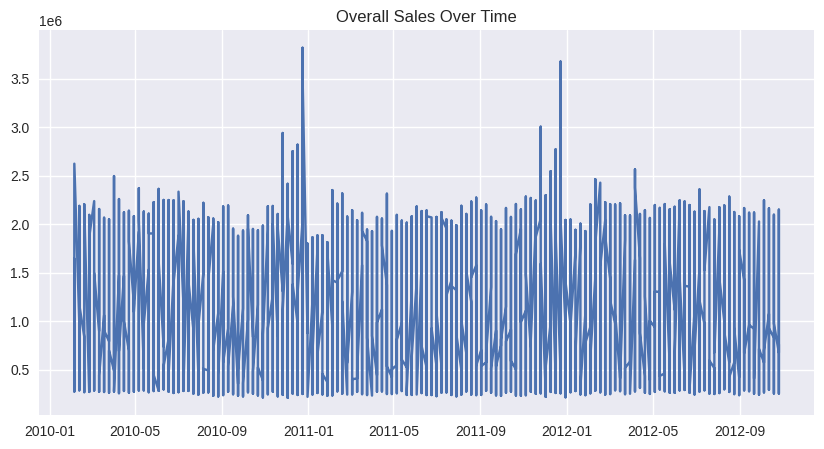

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Weekly_Sales'])
plt.title('Overall Sales Over Time')
plt.show()

In [7]:
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
store_sales.head(10)

,Weekly_Sales
Store,
20,2.107677e+06
4,2.094713e+06
14,2.020978e+06
13,2.003620e+06
2,1.925751e+06
10,1.899425e+06
27,1.775216e+06
6,1.564728e+06
1,1.555264e+06


In [8]:
stores = [1, 20, 33]

In [9]:
df_selected = df[df['Store'].isin(stores)]

series_dict = {}

for store in stores:
    temp = df_selected[df_selected['Store'] == store].copy()
    temp = temp.sort_values('Date')
    temp.set_index('Date', inplace=True)
    temp = temp.asfreq('W-FRI') # Explicitly set the frequency
    series_dict[f'Store_{store}'] = temp['Weekly_Sales']

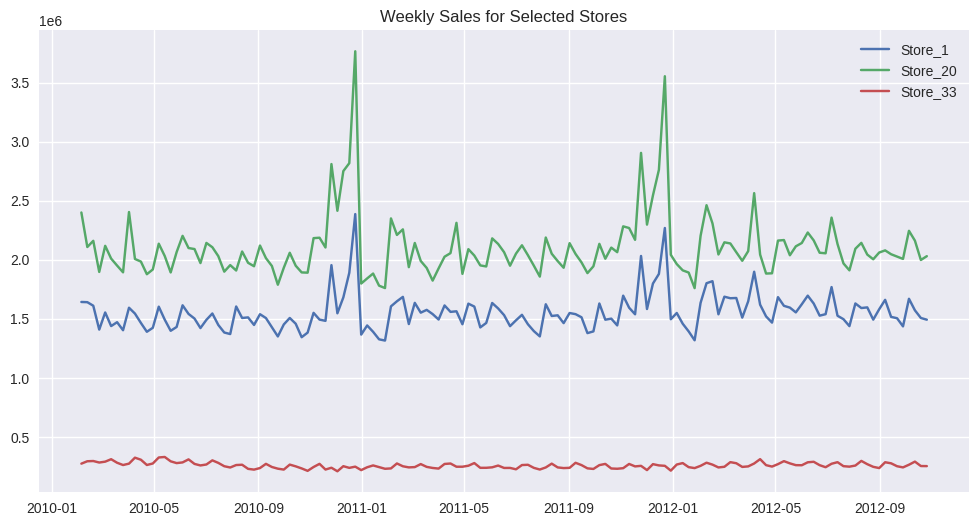

In [10]:
plt.figure(figsize=(12,6))

for name, series in series_dict.items():
    plt.plot(series, label=name)

plt.legend()
plt.title("Weekly Sales for Selected Stores")
plt.show()

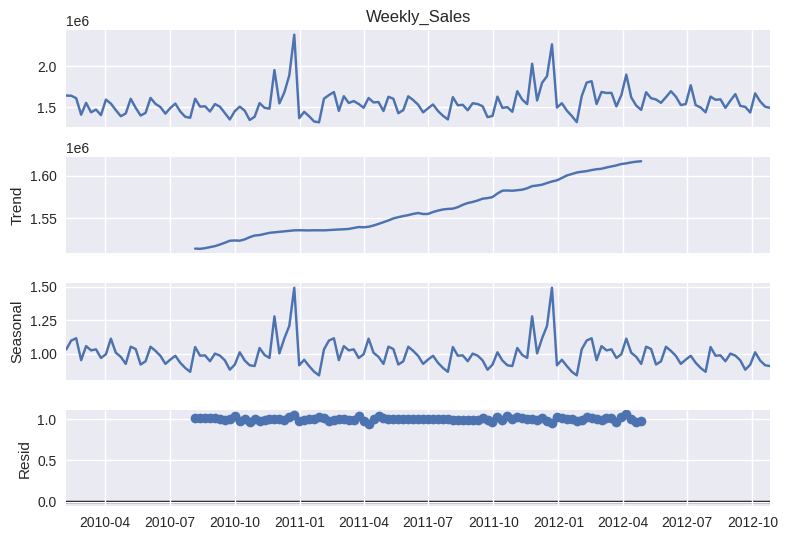

In [11]:
series = series_dict['Store_1']

decomposition = seasonal_decompose(series, model='multiplicative', period=52)

decomposition.plot()
plt.show()

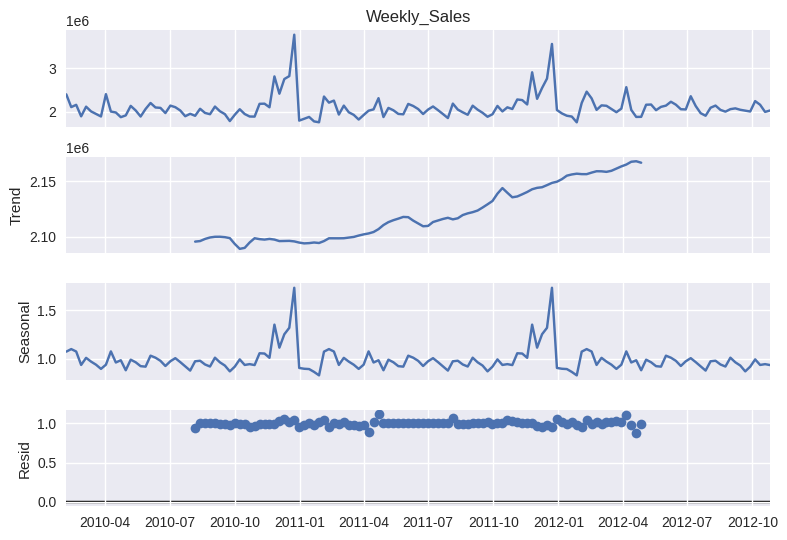

In [12]:
series = series_dict['Store_20']

decomposition = seasonal_decompose(series, model='multiplicative', period=52)

decomposition.plot()
plt.show()

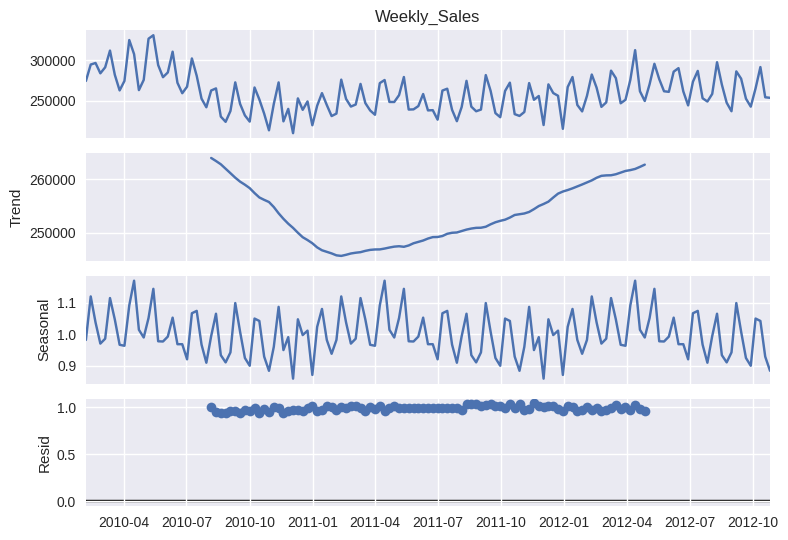

In [13]:
series = series_dict['Store_33']

decomposition = seasonal_decompose(series, model='multiplicative', period=52)

decomposition.plot()
plt.show()

In [14]:
result = adfuller(series_dict['Store_20'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.39373869285483
p-value: 3.4912952838128377e-06


<Figure size 1200x500 with 0 Axes>

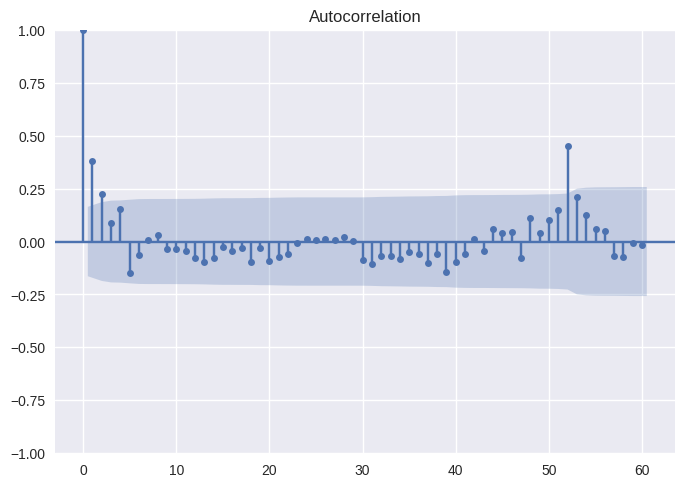

<Figure size 1200x500 with 0 Axes>

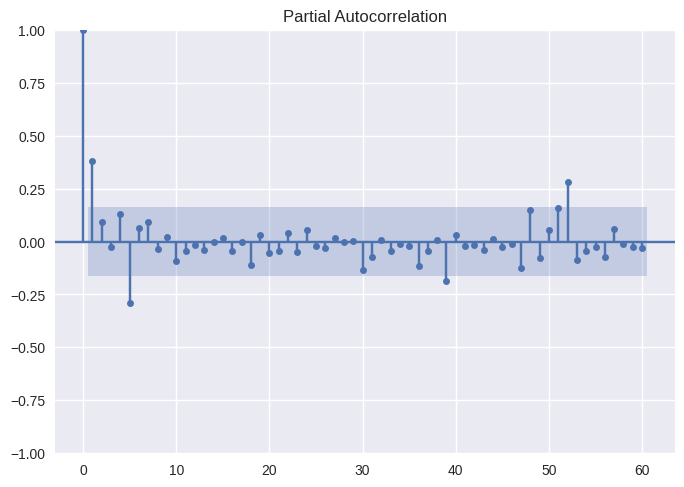

In [15]:
series = series_dict['Store_20']

plt.figure(figsize=(12,5))
plot_acf(series, lags=60)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(series, lags=60)
plt.show()

In [16]:
model = SARIMAX(series_dict['Store_20'],
        order=(1,0,1),
        seasonal_order=(0,0,1,52))

results = model.fit()
print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  143
Model:             SARIMAX(1, 0, 1)x(0, 0, 1, 52)   Log Likelihood               -1977.883
Date:                            Wed, 29 Apr 2026   AIC                           3963.765
Time:                                    14:37:25   BIC                           3975.617
Sample:                                02-05-2010   HQIC                          3968.581
                                     - 10-26-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9980      0.008    126.433      0.000       0.983       1.013
ma.L1         -0.6740      0.050   

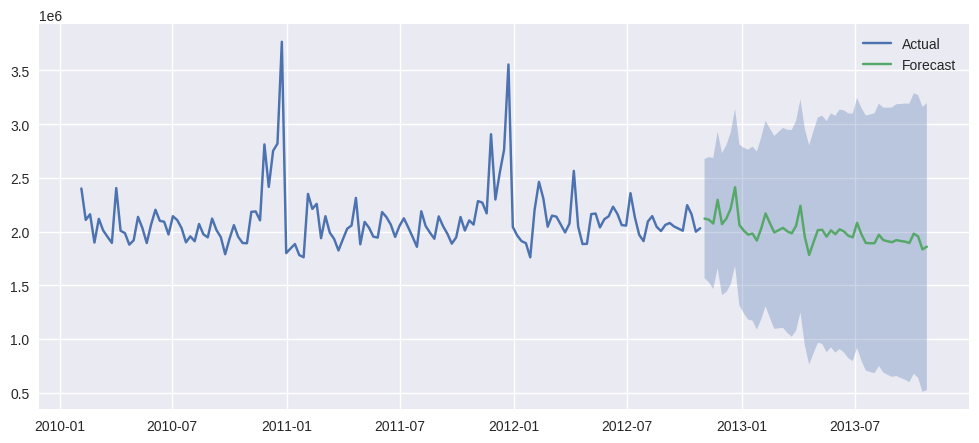

In [17]:
forecast = results.get_forecast(steps=52)
pred = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12,5))
plt.plot(series_dict['Store_20'], label='Actual')
plt.plot(pred, label='Forecast')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 alpha=0.3)

plt.legend()
plt.show()

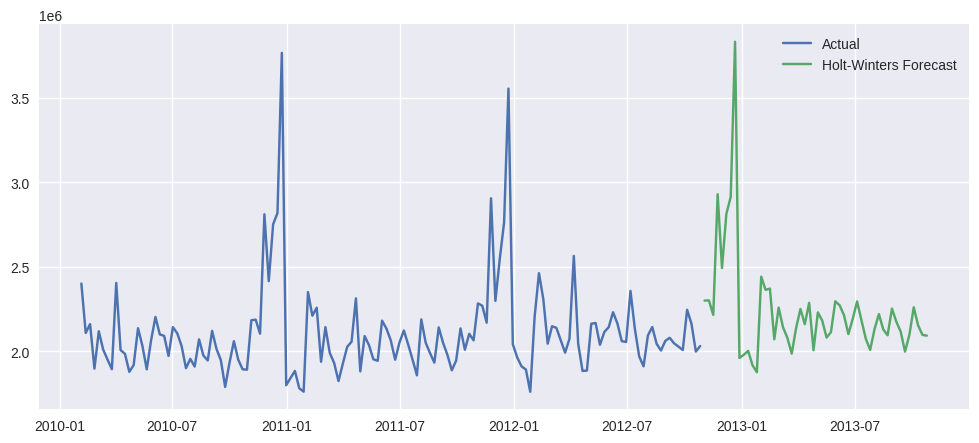

In [18]:
hw_model = ExponentialSmoothing(
    series_dict['Store_20'],
    trend='add',
    seasonal='add',
    seasonal_periods=52
)

hw_fit = hw_model.fit()
hw_forecast = hw_fit.forecast(52)

plt.figure(figsize=(12,5))
plt.plot(series_dict['Store_20'], label='Actual')
plt.plot(hw_forecast, label='Holt-Winters Forecast')
plt.legend()
plt.show()

In [19]:
store20 = df[df['Store'] == 20].copy()
store20 = store20.sort_values('Date')

In [20]:
store20['lag_1'] = store20['Weekly_Sales'].shift(1)
store20['lag_2'] = store20['Weekly_Sales'].shift(2)
store20['lag_52'] = store20['Weekly_Sales'].shift(52)
store20['rolling_mean_4'] = store20['Weekly_Sales'].rolling(window=4).mean()
store20['rolling_mean_12'] = store20['Weekly_Sales'].rolling(window=12).mean()

In [21]:
ml_data = store20.dropna()

In [22]:
features = ['lag_1', 'lag_2', 'lag_52', 'rolling_mean_4', 'rolling_mean_12']

X = ml_data[features]
y = ml_data['Weekly_Sales']

In [23]:
split = int(len(ml_data) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [24]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [25]:
preds = rf_model.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 66522.00234210557
RMSE: 85890.04959552558


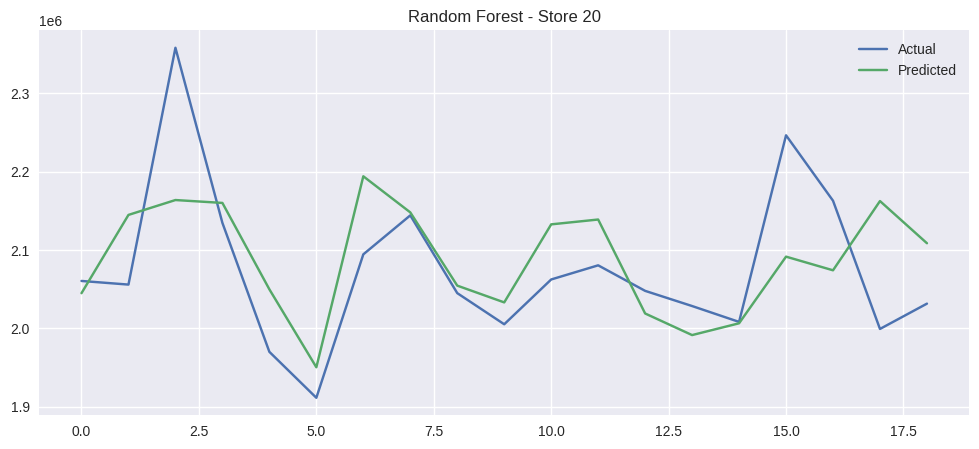

In [27]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title("Random Forest - Store 20")
plt.show()

In [28]:
mlp = MLPRegressor(
    hidden_layer_sizes=(50, 25),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)
nn_preds = mlp.predict(X_test)

In [29]:
mae_nn = mean_absolute_error(y_test, nn_preds)
rmse_nn = np.sqrt(mean_squared_error(y_test, nn_preds))

print("NN MAE:", mae_nn)
print("NN RMSE:", rmse_nn)

NN MAE: 209280.56432385262
NN RMSE: 229978.18251766192


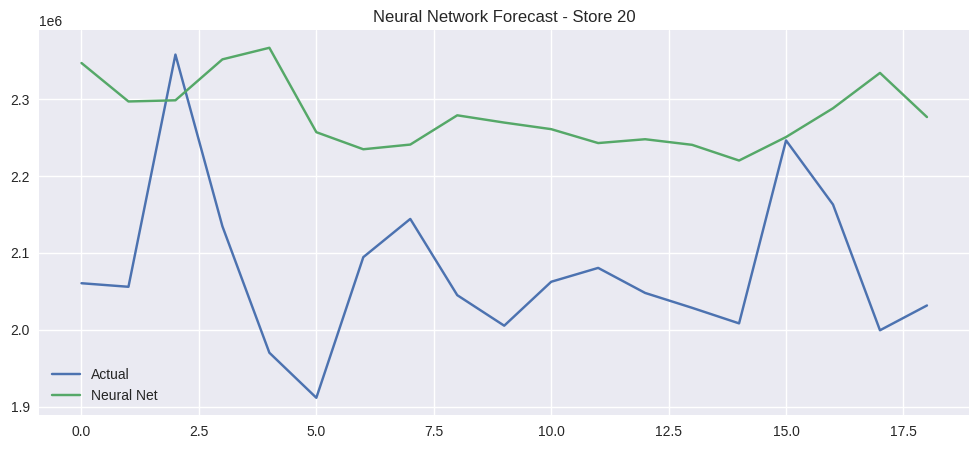

In [30]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(nn_preds, label="Neural Net")
plt.legend()
plt.title("Neural Network Forecast - Store 20")
plt.show()

In [31]:
stores = [1, 20, 33]

results = {}

for store in stores:
    series = series_dict[f'Store_{store}']

    hw_model = ExponentialSmoothing(
        series,
        trend='add',
        seasonal='add',
        seasonal_periods=52
    )

    hw_fit = hw_model.fit()
    hw_forecast = hw_fit.forecast(52)

    results[f"Store_{store}"] = {
        "series": series,
        "forecast_hw": hw_forecast,
        "model_hw": hw_fit
    }